# Global Interpretation Methods: In-class Exercise 09-2

## Goal

Apply what you have learned about global interpretation methods.


## Data

German Credit:

The dataset contains 1000 observations with 21 features and a binary target variable, indicating credit risk. For illustrative purposes, we only consider 8 of the 21 features in the following:

We load the dataset using `fetch_openml()` and then select the following features:

- `age`  
- `credit_amount`  
- `duration`  
- `credit_history`  
- `employment`  
- `personal_status`  
- `purpose`

After selecting the features, categorical variables are one-hot encoded without dropping any category, and then combined with the numerical features to construct the final design matrix `X`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml

# Load the German credit dataset
data = fetch_openml(name='credit-g', version=1, as_frame=True)
X = data.data
y = data.target

selected_features = ["age", "credit_amount", "duration", "credit_history", 
                    "employment", "personal_status", "purpose"]
X = X[selected_features]

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# One-hot encode categorical features using pd.get_dummies WITHOUT dropping first category
# This is important to keep the feature columns aligned with the R solution.
X_categorical_encoded = pd.get_dummies(X[categorical_features], drop_first=False)

# Combine numerical and encoded categorical features
X_numerical = X[numerical_features]
X = pd.concat([X_numerical, X_categorical_encoded], axis=1)

Numerical features: ['age', 'credit_amount', 'duration']
Categorical features: ['credit_history', 'employment', 'personal_status', 'purpose']


### 1.1 Fit a Random Forest

Fit a random forest on some training data to predict credit risk.

We split the dataset into training and test sets (e.g., 80% training, 20% test), and fit a `RandomForestClassifier` from `scikit-learn` on the training data.

In [2]:
#===SOLUTION===

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

seed = 42
rng = np.random.default_rng(seed)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

rf_model = RandomForestClassifier(max_depth=10, random_state=seed)

rf_model.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, rf_model.predict(X_train))
print(f"Random forest model trained. Training accuracy: {train_accuracy:.3f}")


Random forest model trained. Training accuracy: 0.910


### 1.2 Compute PDP of `personal_status`

Since the decision of whether a person gets a loan can have serious implications on their life, banks are subject to regulatory oversight and must be able to explain the decisions made by their models. Looking at individual trees in a random forest is not feasible to understand the model's behavior in aggregate. Therefore, model-agnostic interpretation methods such as PDPs can help reveal the underlying mechanisms and assess fairness.

In this task, we focus on evaluating the feature effect of `personal_status` to check whether the model potentially discriminates against specific groups. Compute and visualize the PDP of the `personal_status` feature using the test data and interpret the results.

You can utilize `PartialDependenceDisplay` from `sklearn`. However, to align the plots with the R solution, we will use a custom implementation in the Python solution.


<div style="border-left: 4px solid #f39c12; padding: 1em; background-color: #fcf8e3; color: #8a6d3b; margin: 1em 0;">
<strong>Note:</strong> According to OpenML, the features in <code>personal_status</code> contain only four categories:
<ul>
  <li>female dev/dep/mar</li>
  <li>male dev/sep</li>
  <li>male mar/wid</li>
  <li>male single</li>
</ul>
This set of unique values differs from the R solution. This may be due to a possible typo in the 
<a href="https://www.openml.org/search?type=data&status=active&id=31&sort=runs" target="_blank">OpenML German Credit Dataset</a>, 
where "female single" appears to be mis-spelled as "male single".
</div>

<details><summary>Hint 1:</summary>
You can simulate the PDP by manually setting one-hot encoded `personal_status_*` variables to isolate the effect of each category while holding other inputs constant. Use `predict_proba()` to obtain class probabilities.
</details>

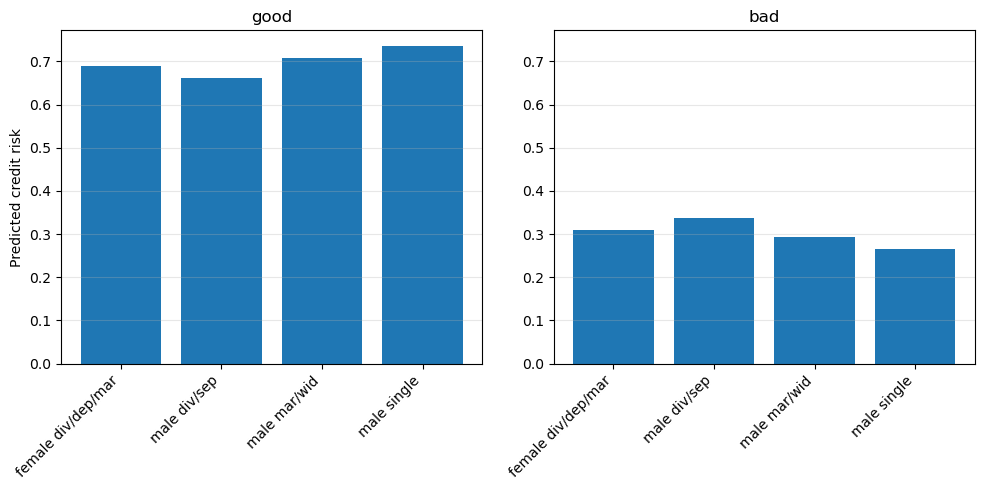

In [3]:
#===SOLUTION===

import matplotlib.pyplot as plt


# Get personal status features
status_features = [col for col in X.columns if col.startswith('personal_status_')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

def compute_pdp_for_class(class_idx):
    """Function to compute PDP values for a specific class."""
    pdp_values = []
    feature_names = []
    for feature in status_features:
        X_temp = X_test.copy()
        X_temp[feature] = 1
        other_features = [f for f in status_features if f != feature]
        X_temp[other_features] = 0
        
        # Get predictions for the specific class
        pred = rf_model.predict_proba(X_temp)[:, class_idx].mean()
        pdp_values.append(pred)
        feature_names.append(feature.replace('personal_status_', ''))
    return pdp_values, feature_names

# Plot for good credit (class 1)
pdp_values_good, feature_names = compute_pdp_for_class(1)
x_pos = np.arange(len(feature_names))
ax1.bar(x_pos, pdp_values_good)
ax1.set_title('good')
ax1.set_ylabel('Predicted credit risk')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(feature_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Plot for bad credit (class 0)
pdp_values_bad, _ = compute_pdp_for_class(0)
ax2.bar(x_pos, pdp_values_bad)
ax2.set_title('bad')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(feature_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Align y-axis limits for both subplots
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

Question: what observation have you obtained?

===SOLUTION===

All customers, regardless of their personal status and gender, have on average a high probability of being a low (good) risk for the bank. The average marginal prediction for divorced or separated male customers reveals a slightly higher risk for this group.

### 1.3 Analyse the corresponding ALE plot

Because ALE (Accumulated Local Effects) accumulate effects in a defined direction, the feature values must follow an order by definition. However, categorical or nominal features like `personal_status` do not have a natural order. To derive an artificial order, Molnar (2022, Chapter 8.2) proposes sorting the feature of interest $x_S$ based on their similarity using the effects conditioned on the remaining features $x_{-S}$.

In this task, we compute ALE effects for each category of `personal_status` for both outcome classes and visualize the results. Then, compare the ALE plots to the previously computed PDPs to analyze how the methods differ in presenting the feature's influence.


Similar to the previous exercises, we will present a custom implementation of ALE in the Python solution.

<details><summary>Hint 1:</summary>
You can compute ALE effects for each category by comparing its mean prediction to the overall mean prediction. The sorted differences then form the ALE values, which are visualized in a bar plot.
</details>

Overall mean prediction (class=good): 0.709
Mean prediction for female div/dep/mar (good): 0.670
Mean prediction for male div/sep (good): 0.634
Mean prediction for male mar/wid (good): 0.663
Mean prediction for male single (good): 0.749


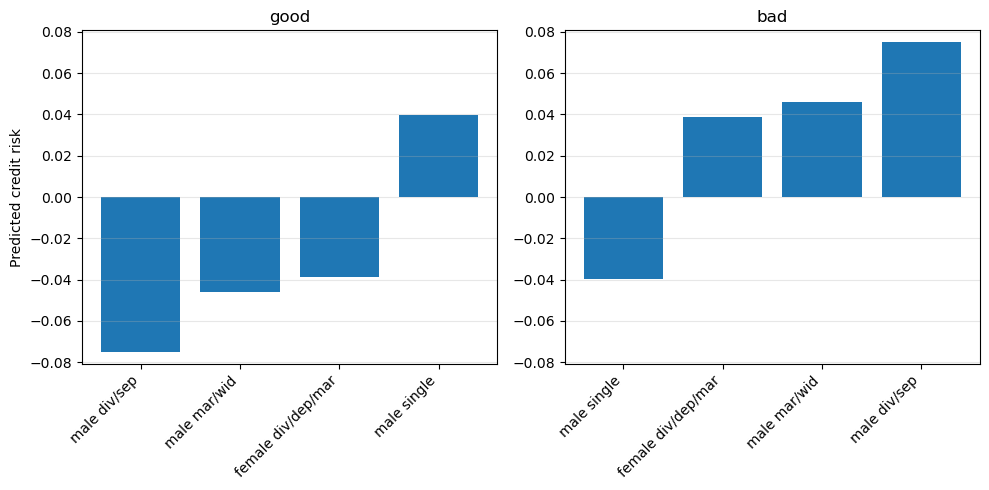

In [4]:
#===SOLUTION===

from sklearn.base import BaseEstimator


def compute_ale_effects(
    model: BaseEstimator, 
    X_test: pd.DataFrame, 
    features: list[str], 
    class_idx: int = 1,
    feature_prefix: str = ""
) -> tuple[dict[str, float], dict[str, float], list[str], list[float]]:
    """
    Compute Accumulated Local Effects (ALE) for categorical features.
    
    Args:
        model: The trained model with predict_proba method
        X_test: Test dataset
        features: List of feature names to compute ALE for
        class_idx: Index of the class to compute ALE for (default: 1 for "good")
        feature_prefix: Prefix to remove from feature names for display (default: "")
        
    Returns:
        status_means: Dictionary of mean predictions for each feature
        ale_effects: Dictionary of ALE effects for each feature
        sorted_categories: List of categories sorted by effect size
        sorted_effects: List of effects sorted by effect size
    """
    predict_func = lambda X: model.predict_proba(X)[:, class_idx]
    y_pred = predict_func(X_test)
    overall_mean = y_pred.mean()
    
    # Compute the average prediction for each category in features
    status_means = {}
    for feature in features:
        # Create mask for samples with this feature
        feature_mask = X_test[feature] == 1
        
        # Calculate mean predictions for this feature
        feature_mean = y_pred[feature_mask].mean()
        
        # Store the means with a cleaned feature name
        clean_name = feature.replace(feature_prefix, '')
        status_means[clean_name] = feature_mean
    
    # Calculate ALE effects as the difference from the overall mean
    ale_effects = {feature: mean - overall_mean for feature, mean in status_means.items()}
    
    # Sort by effect size for better visualization
    categories = list(ale_effects.keys())
    effects = list(ale_effects.values())
    sorted_indices = np.argsort(effects)
    sorted_categories = [categories[i] for i in sorted_indices]
    sorted_effects = [effects[i] for i in sorted_indices]
    
    return status_means, ale_effects, sorted_categories, sorted_effects

# Define predict_good function
def predict_good(X):
    return rf_model.predict_proba(X)[:, 1]

status_means_good, ale_effects_good, sorted_categories_good, sorted_effects_good = compute_ale_effects(
    rf_model, X_test, status_features, class_idx=1, feature_prefix="personal_status_"
)

status_means_bad, ale_effects_bad, sorted_categories_bad, sorted_effects_bad = compute_ale_effects(
    rf_model, X_test, status_features, class_idx=0, feature_prefix="personal_status_"
)

print(f"Overall mean prediction (class=good): {predict_good(X_test).mean():.3f}")
for feature, mean in status_means_good.items():
    print(f"Mean prediction for {feature} (good): {mean:.3f}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot the ALE effects for good class
ax1.bar(sorted_categories_good, sorted_effects_good)
ax1.set_title('good')
ax1.set_ylabel('Predicted credit risk')
ax1.set_xticks(range(len(sorted_categories_good)))
ax1.set_xticklabels(sorted_categories_good, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

# Plot the ALE effects for bad class
ax2.bar(sorted_categories_bad, sorted_effects_bad)
ax2.set_title('bad')
ax2.set_xticks(range(len(sorted_categories_bad)))
ax2.set_xticklabels(sorted_categories_bad, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Align y-axis limits for both subplots
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


Question: what is your observation?

===SOLUTION===
In comparison to the PDP, we now see that there are clear gender-specific differences, e.g., that divorced or separated male customers show a much higher risk.

## 2 PFI

### 2.1 A synthetic example

Download the `extrapolation.csv` dataset and remove the column that only contains row indices (such as `"X"` or `"Unnamed: 0"`). Fit a linear regression model on the training data. Do not examine the model’s coefficients or perform any exploratory data analysis at this stage.

Instead, split the data into training and test sets, and assess the model’s performance by computing the MSE on the test data.

In [5]:
#===SOLUTION===

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


synthetic_df = pd.read_csv("../data/extrapolation.csv")
if "X" in synthetic_df.columns:
    synthetic_df = synthetic_df.drop(columns=["X"])

# Check for and remove the row index column that was saved in the csv file
if "Unnamed: 0" in synthetic_df.columns:
    synthetic_df = synthetic_df.drop(columns=["Unnamed: 0"])

X_synthetic = synthetic_df.drop(columns=["y"])
y_synthetic = synthetic_df["y"]

X_train_synthetic, X_test_synthetic, y_train_synthetic, y_test_synthetic = train_test_split(
    X_synthetic, y_synthetic, test_size=0.2, random_state=seed
)

linear_model = LinearRegression()
linear_model.fit(X_train_synthetic, y_train_synthetic)

y_pred_synthetic = linear_model.predict(X_test_synthetic)
mse_synthetic = mean_squared_error(y_test_synthetic, y_pred_synthetic)
print(f"MSE: {mse_synthetic:.3f}")


MSE: 0.010


## 2.2 Calculate and interpret PFI values

Apply Permutation Feature Importance to the model (on test data) and plot the results.

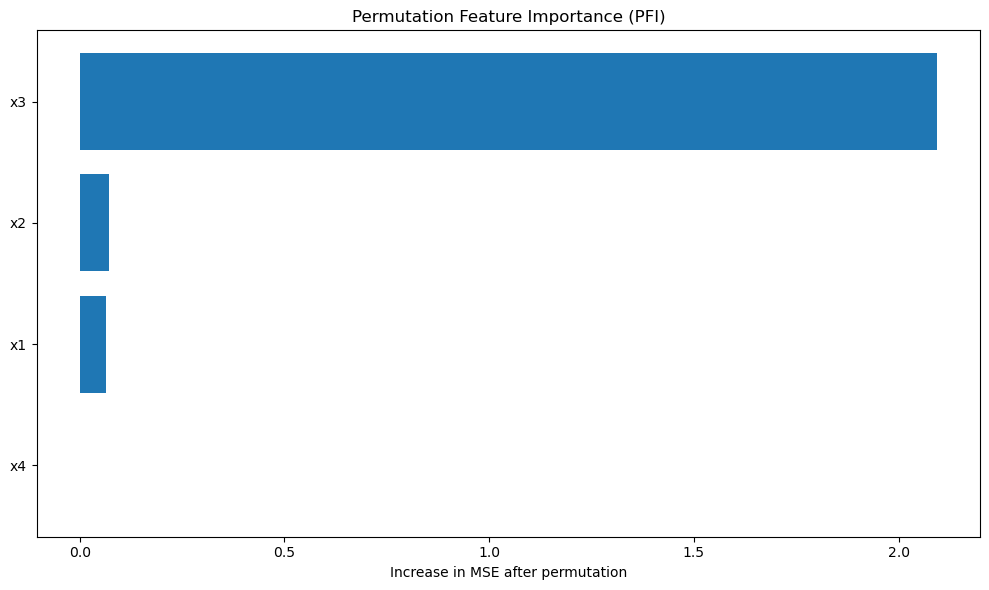

In [6]:
#===SOLUTION===

from sklearn.inspection import permutation_importance


pfi_results = permutation_importance(
    linear_model, 
    X_test_synthetic, 
    y_test_synthetic, 
    scoring="neg_mean_squared_error",
    n_repeats=10, 
    random_state=seed
)

importance_values = pfi_results.importances_mean

feature_names = X_synthetic.columns
sorted_indices = importance_values.argsort()[::-1]
sorted_importance = importance_values[sorted_indices]
sorted_features = [feature_names[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(sorted_features))
ax.barh(y_pos, sorted_importance)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_features)

ax.set_xlabel("Increase in MSE after permutation")
ax.set_title("Permutation Feature Importance (PFI)")
# Most important feature at the top
ax.invert_yaxis()  

plt.tight_layout()
plt.show()

Question: what is your observation?

===SOLUTION===

$X_3$ is the most important feature, with $X_1$ and $X_2$ sharing the second place. PFI considers $X_4$ to be irrelevant.

## 2.3 Exploratory analysis

Perform an exploratory analysis of the data (correlation structure between features and with $y$) and print the model’s coefficients and intercept. What additional insight into the relationship of the features with $y$ do we gain by looking at the correlation structure of the covariates in addition to the PFI (assuming that all dependencies are linear)?

Correlation Matrix:
           y        x1        x2        x3        x4
y   1.000000  0.024099  0.024509  0.995393  0.003472
x1  0.024099  1.000000  0.999950  0.025476 -0.047783
x2  0.024509  0.999950  1.000000  0.025860 -0.047985
x3  0.995393  0.025476  0.025860  1.000000 -0.000650
x4  0.003472 -0.047783 -0.047985 -0.000650  1.000000

Model Coefficients:
x1: -0.182943
x2: 0.179477
x3: 1.007378
x4: 0.006375
Intercept: 0.004939


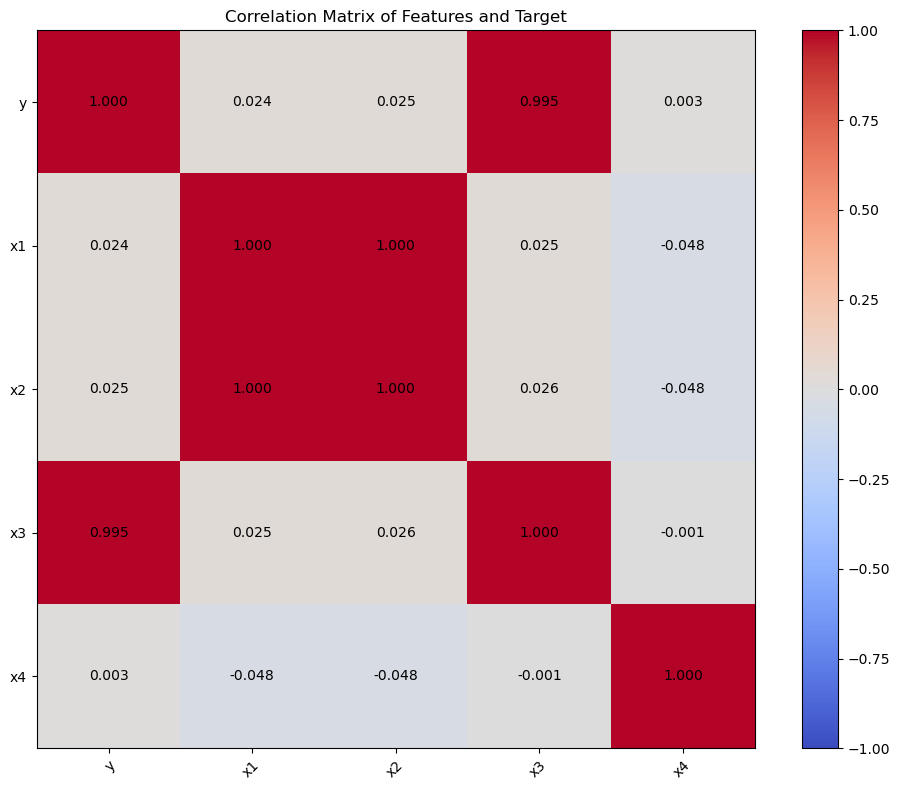

In [7]:
#===SOLUTION===

# Calculate correlation matrix for features and target
correlation_matrix = pd.concat([y_synthetic, X_synthetic], axis=1).corr()
print("Correlation Matrix:")
print(correlation_matrix)

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, linear_model.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {linear_model.intercept_:.6f}")

# Visualize correlation matrix as a heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.index)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black")

ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.index)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

cbar = fig.colorbar(im)
plt.title('Correlation Matrix of Features and Target')
plt.tight_layout()
plt.show()


Question: what is your observation?

===SOLUTION===

If we know the dependency structure of the covariates we can infer whether or not the PFI value is nonzero due to a dependency with the covariates or not. In our example we now know that $X_3$ is independent of its covariates, so we hypothesize that $x_3$ is actually dependent with $y$. Since $X_1$, $X_2$ are dependent, for those variables we cannot infer anything about the dependency with $y$ with the covariates dependency structure and PFI alone.

## Summary

In this exercise, we analyzed an example of ALE on a categorical target and deepened our understanding of PFI.